# 28 - Dropout

**Section:** Regularization | **Prereqs:** `Regularization/Mini_batch.ipynb` | **Next:** `Regularization/Weight_Regularization_(L2).ipynb`

Dropout zeroes a random subset of activations on every forward pass during
training. The network can never rely on any single unit being present, so it
learns redundant, distributed representations instead of brittle ones.

**Two experiments:** a full sweep of dropout rates 0.0 to 0.9 on the
interlocking-doughnuts dataset, then a heavily regularised model on Iris.

**What to expect from the sweep.** Accuracy vs dropout rate is an inverted U.
Zero dropout overfits; a bit helps; too much (0.5+ on a small net) starves the
model of capacity and both curves fall. The peak position depends on the model
and the data - there is no universal good value, though 0.2-0.5 is the usual
starting range.

**Dropout is not free.** It slows convergence (each step trains a different
sub-network) and it only pays off when the model was overfitting to begin with.
On a small underfitting model it simply makes things worse - which the Iris
example at the end demonstrates.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader , TensorDataset
import torch.nn.functional as F


from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
%matplotlib inline

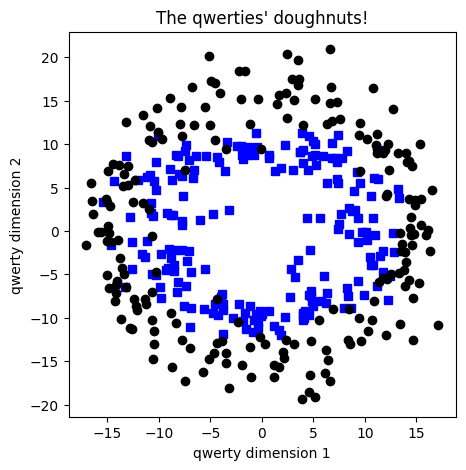

In [ ]:
# Two interleaved noisy rings. Not linearly separable, and the classes are
# close enough that a large network will happily memorise the noise - exactly
# the situation where dropout should help.
nPerClust = 200

th = np.linspace(0,4*np.pi,nPerClust)
r1 = 10
r2 = 15

# generate data
a = [ r1*np.cos(th) + np.random.randn(nPerClust)*3 , r1*np.sin(th) + np.random.randn(nPerClust) ]
b = [ r2*np.cos(th) + np.random.randn(nPerClust) , r2*np.sin(th) + np.random.randn(nPerClust)*3 ]

# true labels
labels_np = np.vstack((np.zeros((nPerClust,1)),np.ones((nPerClust,1))))

# concatanate into a matrix
data_np = np.hstack((a,b)).T

# convert to a pytorch tensor
data = torch.tensor(data_np).float()
labels = torch.tensor(labels_np).float()

# show the data
fig = plt.figure(figsize=(5,5))
plt.plot(data[np.where(labels==0)[0],0],data[np.where(labels==0)[0],1],'bs')
plt.plot(data[np.where(labels==1)[0],0],data[np.where(labels==1)[0],1],'ko')
plt.title("The qwerties' doughnuts!")
plt.xlabel('qwerty dimension 1')
plt.ylabel('qwerty dimension 2')
plt.show()

In [ ]:
# Standard split and loaders.
data_train, data_test, label_train, label_test = train_test_split(data,labels,test_size=0.2)

data_train = TensorDataset(data_train, label_train)
data_test = TensorDataset(data_test, label_test)


batchSize = 16 # Better to hard code batchsize
train_loader = DataLoader(data_train,batch_size =batchSize, shuffle=True)
test_loader = DataLoader(data_test, batch_size=data_test.tensors[0].shape[0])

In [ ]:
# Batch shapes: (16,2) features and (16,1) labels. The label shape matters for
# BCEWithLogitsLoss, which needs targets shaped like the output.
for a,b in train_loader:
  print(a.shape,b.shape)

torch.Size([16, 2]) torch.Size([16, 1])
torch.Size([16, 2]) torch.Size([16, 1])
torch.Size([16, 2]) torch.Size([16, 1])
torch.Size([16, 2]) torch.Size([16, 1])
torch.Size([16, 2]) torch.Size([16, 1])
torch.Size([16, 2]) torch.Size([16, 1])
torch.Size([16, 2]) torch.Size([16, 1])
torch.Size([16, 2]) torch.Size([16, 1])
torch.Size([16, 2]) torch.Size([16, 1])
torch.Size([16, 2]) torch.Size([16, 1])
torch.Size([16, 2]) torch.Size([16, 1])
torch.Size([16, 2]) torch.Size([16, 1])
torch.Size([16, 2]) torch.Size([16, 1])
torch.Size([16, 2]) torch.Size([16, 1])
torch.Size([16, 2]) torch.Size([16, 1])
torch.Size([16, 2]) torch.Size([16, 1])
torch.Size([16, 2]) torch.Size([16, 1])
torch.Size([16, 2]) torch.Size([16, 1])
torch.Size([16, 2]) torch.Size([16, 1])
torch.Size([16, 2]) torch.Size([16, 1])


In [ ]:
# 2 -> 128 -> 128 -> 1 with dropout after each hidden activation.
# Dropout goes AFTER the activation and never after the output layer -
# dropping logits would just add noise to the prediction.
# One nn.Dropout instance is reused for both positions, which is fine: dropout
# has no parameters, only a rate, and draws a fresh mask on every call.
class Classifier(nn.Module):
    def __init__(self, dropout_rate):
      super().__init__()

      self.input_layer = nn.Linear(2,128)
      self.hidden_layer = nn.Linear(128,128)
      self.output_layer = nn.Linear(128,1)
      self.dropout_layer = nn.Dropout(p=dropout_rate)

    def forward(self,x):

      x = F.relu(self.input_layer(x))

      x = self.dropout_layer(x)
      # can also use x = F.dropout(x, p=self.dr, training=self.training) where, self.training is a bool, as which tell if the model is in training mode

      x = F.relu(self.hidden_layer(x))

      x = self.dropout_layer(x)

      x = self.output_layer(x)

      return x

In [ ]:
# Checking .training - True on a fresh model, False after .eval(). This flag is
# what nn.Dropout reads to decide whether to drop.
## Testing  model

test = Classifier(0)
test_data = torch.randn(16,2)

yhat = test(test_data)
print(yhat, test.training)

test.eval()

test.training



tensor([[0.0109],
        [0.1598],
        [0.0751],
        [0.0660],
        [0.1531],
        [0.0419],
        [0.0531],
        [0.2049],
        [0.2366],
        [0.0693],
        [0.1696],
        [0.0009],
        [0.0175],
        [0.0874],
        [0.0548],
        [0.0299]], grad_fn=<AddmmBackward0>) True


False

In [ ]:
# Model factory plus training function, parameterised by dropout rate.
# BCEWithLogitsLoss again, so the decision rule is `yhat > 0`.
# Loss is collected per batch and averaged per epoch; assigning losses[epoch]
# inside the batch loop would record only the final batch.
def makeModel(drr):

  model = Classifier(drr)

  lr = 0.001
  optimizer = torch.optim.SGD(model.parameters(), lr=lr)

  lossFunc = nn.BCEWithLogitsLoss()

  return model, optimizer,lossFunc


def trainModel(dropout_rate):

  model, optimizer, lossFunc = makeModel(dropout_rate)

  epochs = 3000

  train_accuracy = []
  test_accuracy = []
  losses = torch.zeros(epochs)

  for epoch in range(epochs):

    batch_accuracy = []
    batch_loss = []
    model.train()

    for x,y in train_loader:

      yhat = model(x)

      loss = lossFunc(yhat,y)
      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      batch_accuracy.append( (100* torch.mean(((yhat > 0) == y).float()).item() ))


    losses[epoch] = np.mean(batch_loss)
    train_accuracy.append(np.mean(batch_accuracy))
    model.eval()
    with torch.no_grad():
        X_val, y_val = next(iter(test_loader))
        y_pred = model(X_val)
        test_acc = 100 * ((y_pred > 0).float() == y_val).float().mean().item()
        test_accuracy.append(test_acc)

  return losses, test_accuracy, train_accuracy



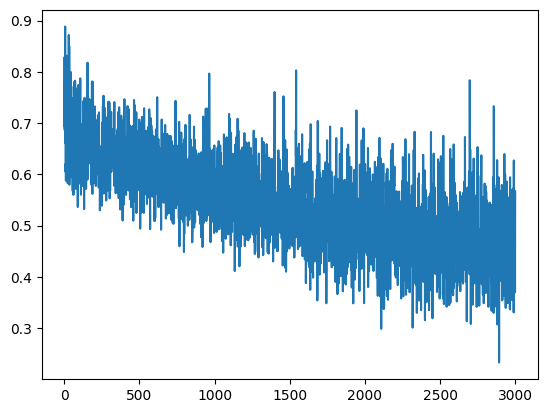

In [ ]:
# One run at 25% dropout.
losses, test_accuracy, train_accuracy = trainModel(0.25)

plt.plot(losses.detach());


In [ ]:
# Train vs test accuracy. With dropout the two curves stay much closer than in
# an unregularised run - that narrowing IS the effect of regularisation.
# Train accuracy is also measured WITH dropout active, so it is pessimistic.
plt.plot(test_accuracy, "r--",label ="test accuracy")
plt.plot(train_accuracy, "b--", label="Train accuracy")
plt.legend();


In [ ]:
# The sweep: dropout rates 0.0 to 0.9.
dropout_rates = np.arange(10)/10
dropout_rates

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

In [ ]:
# Ten full training runs. The slow cell of this notebook.
allLosses = []
allTest_acc = []
allTrain_acc = []


for i in dropout_rates:
  losses, test_accuracy, train_accuracy = trainModel(i)

  allLosses.append(losses)
  allTest_acc.append(test_accuracy)
  allTrain_acc.append(train_accuracy)



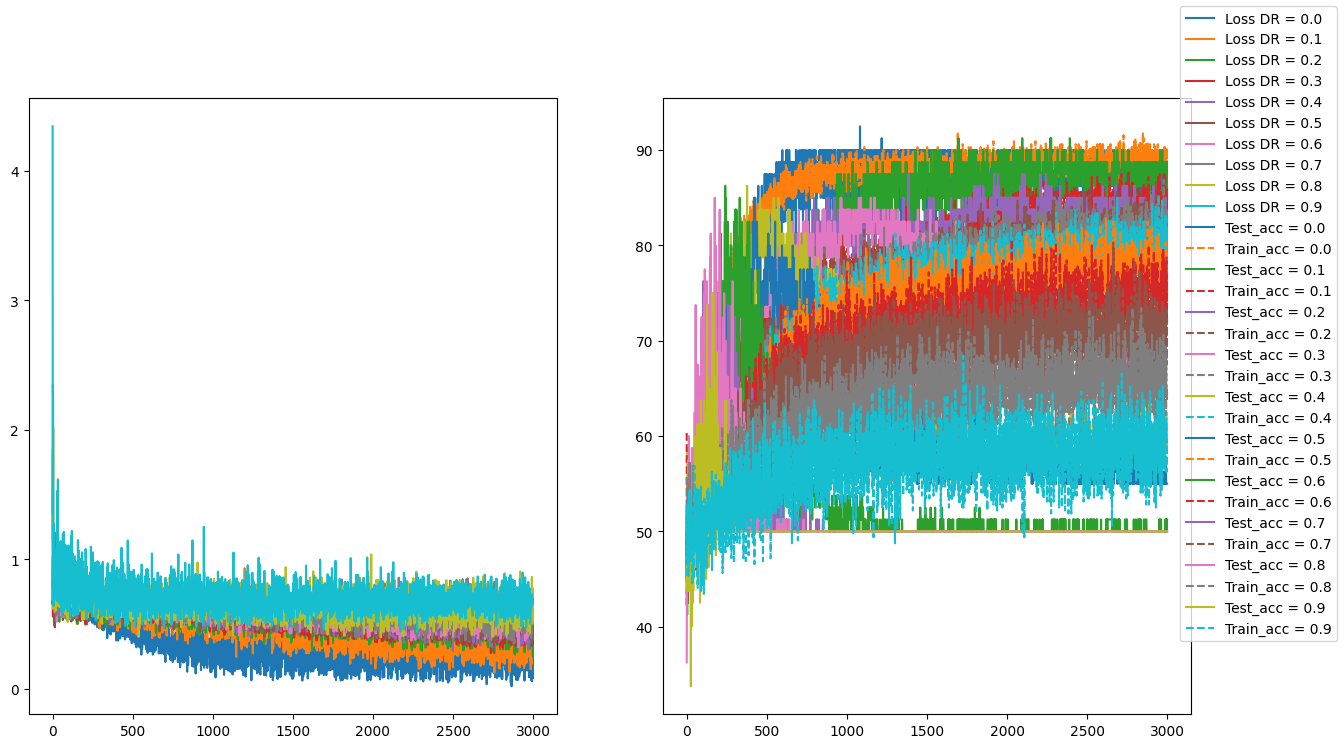

In [ ]:
# All runs overlaid - crowded, but the trend is visible: higher dropout gives
# noisier losses and slower convergence.
fig ,ax = plt.subplots(1,2,figsize=(15,8))
for i in range(10):
  ax[0].plot(allLosses[i].detach(), label=f"Loss DR = {dropout_rates[i]}")
  ax[1].plot(allTest_acc[i],"-", label=f"Test_acc = {dropout_rates[i]}")
  ax[1].plot(allTrain_acc[i],"--", label=f"Train_acc = {dropout_rates[i]}")
fig.legend()

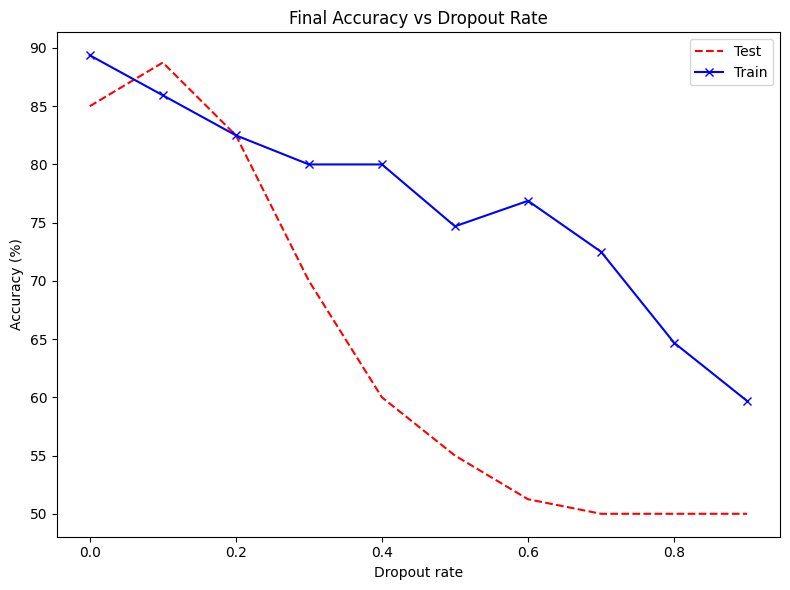

In [ ]:
# The summary plot. Expect an inverted U on the test curve: some dropout beats
# none, too much is worse than none. Train accuracy falls monotonically, since
# dropout only ever makes the training task harder.
# The gap between the two lines is the overfitting that dropout is closing.
import matplotlib.pyplot as plt
from matplotlib import colormaps
import numpy as np

dr      = np.asarray(dropout_rates)
final_test  = [allTest_acc[i][-1]  for i in range(len(dr))]
final_train = [allTrain_acc[i][-1] for i in range(len(dr))]

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(dr, final_test,"r--",label='Test')
ax.plot(dr, final_train,'b-', marker='x', label='Train')

ax.set(title='Final Accuracy vs Dropout Rate',
       xlabel='Dropout rate',
       ylabel='Accuracy (%)')
ax.legend()

plt.tight_layout()
plt.show()


## Drouout in Iris DataSet

In [ ]:
# Second experiment: Iris, only 120 training samples.
iris = load_iris()

data = torch.tensor(iris.data, dtype=torch.float)
target = torch.tensor(iris.target, dtype=torch.long)

In [ ]:
data_train,data_test ,target_train, target_test = train_test_split(data,target,test_size=0.2, shuffle=True)
target_test.shape , data_test.shape

(torch.Size([30]), torch.Size([30, 4]))

In [ ]:
data_train = TensorDataset(data_train,target_train)
data_test = TensorDataset(data_test, target_test)

In [ ]:
batch_size = 8
train_loader = DataLoader(data_train, batch_size=batch_size)
test_loader = DataLoader(data_test, batch_size=data_test.tensors[0].shape[0])

In [ ]:
# A deliberately extreme model: 4 -> 256 -> 256 (x3) -> 3 with p=0.5 dropout
# after every layer.
# Note self.hidden_layer is applied three times - the SAME weights reused, not
# three independent layers. That is a weight-tied network, which is a legitimate
# design but probably unintended here.
class model(nn.Module):
  def __init__(self):
    super().__init__()

    self.input_layer = nn.Linear(4, 256)
    self.hidden_layer = nn.Linear(256,256)


    self.dropout_layer = nn.Dropout(p=0.5)

    self.output_layer = nn.Linear(256,3)

  def forward(self,x):
    x = F.relu(self.input_layer(x))
    x = self.dropout_layer(x)

    x = F.relu(self.hidden_layer(x))
    x = self.dropout_layer(x)

    x = F.relu(self.hidden_layer(x))
    x = self.dropout_layer(x)

    x = F.relu(self.hidden_layer(x))
    x = self.dropout_layer(x)

    return self.output_layer(x)


In [ ]:
# Standard training loop with CrossEntropyLoss.
lossFunc = nn.CrossEntropyLoss()
iris = model()
epochs = 3000
optimizer = torch.optim.SGD(iris.parameters(), lr = 0.001)

losses = torch.zeros(epochs)
train_accuracy = []
test_accuracy = []


for epoch in range(epochs):

  iris.train()
  batch_accuracy = []

  for x, y in train_loader:

    yhat = iris(x)

    loss = lossFunc(yhat,y)
    losses[epoch] = loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    batch_accuracy.append ( 100 * torch.mean( ( torch.argmax(yhat, dim=1) == y ).float() ) )

  train_accuracy.append(np.mean(batch_accuracy))

  iris.eval()
  with torch.no_grad():
    x , y = next(iter(test_loader))
    preds = iris(x)
    test_accuracy.append ( 100 * torch.mean( ( torch.argmax(preds, dim=1) == y ).float() ) )



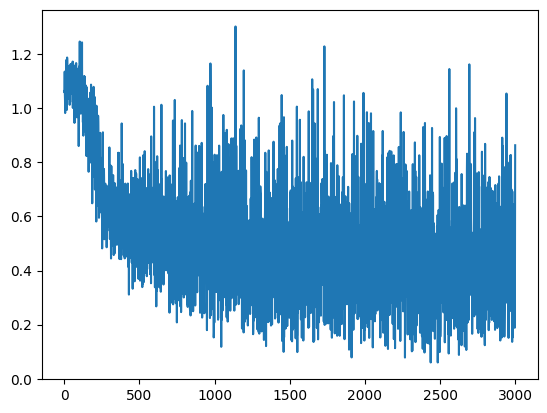

In [ ]:
# The loss barely moves. With half the units dropped at every one of four
# layers, only a small fraction of paths survive a forward pass.
plt.plot(losses.detach());

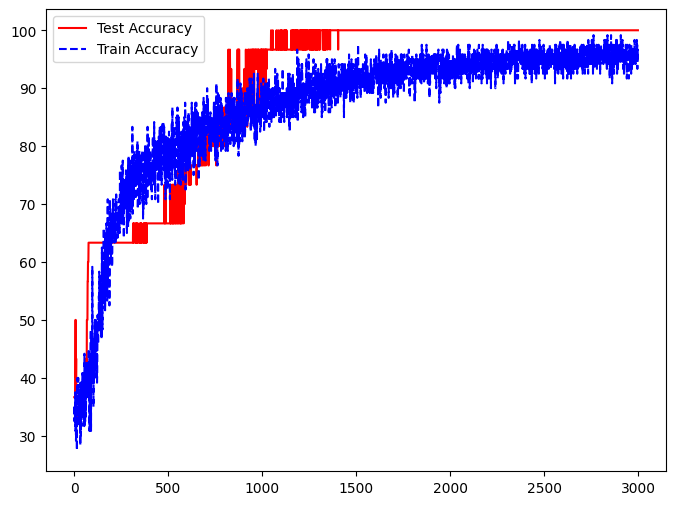

In [ ]:
# Both accuracies stay low. This is the counter-example: dropout on a model
# that was not overfitting in the first place just removes capacity.
# Reach for regularisation when train accuracy is much higher than test
# accuracy - not by default.
plt.figure(figsize=(8,6))
plt.plot(test_accuracy, "r-",label="Test Accuracy")
plt.plot(train_accuracy , "b--", label="Train Accuracy")
plt.legend();